# Exercise Sheet 5 - Student Template

*Generative AI and Visual Synthesis, SoSe 2026*

**Deadline:** 05.06.2026, 10:00 &nbsp;&nbsp;|&nbsp;&nbsp;
**Total:** 40 points (two-week assignment)

| Task | Topic | Points |
|---|---|---:|
| 1 | Optimal discriminator/generator + non-saturating loss | 8 |
| 2 | Conditional DCGAN on Fashion-MNIST | 14 |
| 3 | GAN stabilization study (two variants) | 10 |
| 4 | Conditional control and interpolation | 4 |
| 5 | Confusion matrix on generated data | 4 |
| **Total** | | **40** |

**Submission.** Submit a single ZIP file named `Surname-MatriculationNumber.zip`
containing this completed `.ipynb` notebook and an exported PDF version of it
(the PDF is your report). Use relative paths and make sure the code runs on
Linux, macOS, and Windows. Plots must have informative axis labels, legends,
and captions.


In [2]:
import os
import math
import time
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision
from torchvision import transforms

import matplotlib.pyplot as plt
from sklearn.manifold import TSNE


def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


seed_everything(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---------------------------------------------------------------------------
# Training budget. Adjust these two constants to control how long things run.
#   - NUM_CLASSIFIER_EPOCHS:  20 with linear LR decay starting at epoch 10.
#                             Reaches ~92.5% test accuracy reliably, which
#                             is within ~0.5pp of a 30-epoch run and plenty
#                             for the downstream generated-sample
#                             evaluations.
#   - NUM_GAN_EPOCHS:         5 = smoke test, 10 = full story already
#                             visible (baseline collapses, Variant A
#                             stabilizes), 15 = default sweet spot (Variant
#                             A reaches ~90% classifier accuracy on
#                             generated samples), 20-25 = marginally
#                             crisper, 50+ = diminishing returns.
# Task 3 trains 3 GANs (baseline + 2 variants) using NUM_GAN_EPOCHS each;
# on an H200 this means ~5 min total at the default 15 epochs.
# ---------------------------------------------------------------------------
NUM_CLASSIFIER_EPOCHS = 20
NUM_GAN_EPOCHS = 15

DATA_ROOT = "datasets"

FASHION_CLASSES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]


Using device: cuda


## Task 1 — Optimal Discriminator and Generator (8P) 

**You should write down the steps in latex math format.**

Recall the value function of the GAN minimax game (see lecture and Goodfellow
et al., 2014):

$$
V(D,G)=\mathbb{E}_{x\sim p_{\text{data}}(x)}[\log D(x)] +
       \mathbb{E}_{z\sim p(z)}[\log(1-D(G(z)))]
     = \int_x p_{\text{data}}(x)\log D(x) + p_G(x)\log(1-D(x))\,dx.
$$


### Task 1a — Optimal discriminator (3P)

Derive the optimal discriminator $D^*(x)$ for a fixed generator $G$ in terms of
$p_{\text{data}}(x)$ and $p_G(x)$.

*Hint:* For fixed $a,b>0$ find the maximum of $f(y)=a\log y + b\log(1-y)$ on
$y\in(0,1)$ by setting $f'(y)=0$.

**Solution**

**Function to maximize**

Let:
* $y = D(x)$
* $a = p_{\text{data}}(x)$
* $b = p_G(x)$

This gives the objective function to maximize:
$$f(y) = a \log(y) + b \log(1-y)$$

**Find the derivative**

To find the maximum, we take the first derivative of $f(y)$ and set it to zero:
$$f'(y) = \frac{a}{y} - \frac{b}{1-y} = 0$$

**Solve for y**

$$\frac{a}{y} = \frac{b}{1-y}$$
$$a(1-y) = by$$
$$a - ay = by$$
$$a = y(a + b)$$
$$y = \frac{a}{a + b}$$

**Substitute the original variables back in**
$$D^*(x) = \frac{p_{\text{data}}(x)}{p_{\text{data}}(x) + p_G(x)}$$

### Task 1b — Generator optimum and equilibrium (3P)

Substitute $D^*$ into $V(D,G)$ and discuss the global minimum of $V(D^*,G)$
over $G$: at which point is it reached, what value does $D^*$ take there, and
what does this mean operationally? You may briefly mention the connection to
the Jensen–Shannon divergence.

**Solution**

**Substitute $D^*$ into $V(D,G)$**
$$V(D^*,G) = \int_x \left[ p_{\text{data}}(x)\log\left(\frac{p_{\text{data}}(x)}{p_{\text{data}}(x) + p_G(x)}\right) + p_G(x)\log\left(\frac{p_G(x)}{p_{\text{data}}(x) + p_G(x)}\right) \right] dx$$

**The Global Minimum**

The global minimum for the generator $G$ is reached when the generated data distribution perfectly matches the real data distribution:
$$p_G(x) = p_{\text{data}}(x)$$

**The Value of $D^*$ at Equilibrium**

At this optimum, if we plug $p_G(x) = p_{\text{data}}(x)$ into the optimal discriminator, we get:
$$D^*(x) = \frac{p_{\text{data}}(x)}{p_{\text{data}}(x) + p_{\text{data}}(x)} = \frac{1}{2}$$

**Operational Meaning**

Operationally, this is a state of perfect equilibrium. The generated samples are completely indistinguishable from real samples. Therefore, the optimal discriminator cannot find any features to tell the difference and is forced to guess randomly (a 50% probability) for every sample.

**Connection to Jensen-Shannon Divergence**

By dividing the numerators and denominators in the $V(D^*,G)$ integral by $2$, the formula matches the definition of the Jensen-Shannon Divergence between $p_{\text{data}}$ and $p_G$, minus a constant:
$$V(D^*,G) = -\log(4) + 2 \cdot JSD(p_{\text{data}} || p_G)$$
Since $JSD \ge 0$, and $JSD = 0$ only when the distributions are identical, the global minimum value of the entire formula is exactly $-\log(4)$.

### Task 1c — Non-saturating generator loss (2P)

The saturating generator loss derived from the minimax objective is

$$\mathcal{L}_G^{\text{sat}} = \mathbb{E}_{z}[\log(1-D(G(z)))],$$

while in practice GANs are trained with the *non-saturating* loss

$$\mathcal{L}_G^{\text{ns}} = -\mathbb{E}_{z}[\log D(G(z))].$$

Explain why $\mathcal{L}_G^{\text{ns}}$ is preferred. Discuss the gradient
signal early in training when $D(G(z))\approx 0$ and clarify that the
optimum is unchanged but optimization is improved.

**Solution** 

**The Problem with Saturating Loss Early in Training**

Early in training, the generator $G$ is bad, and the discriminator $D$ rejects its samples with high confidence. This means $D(G(z)) \approx 0$. 
The gradient of the saturating loss $\mathcal{L}_G^{\text{sat}} = \mathbb{E}_z[\log(1-D(G(z)))]$ with respect to the discriminator's output is $\frac{-1}{1-D(G(z))}$. As $D(G(z)) \to 0$, this gradient magnitude approaches $1$. This leads to very small gradients being passed back to the generator, causing learning to stall when the generator needs to learn the most.

**The Non-Saturating Gradient Signal**

To fix this, we use the non-saturating loss $\mathcal{L}_G^{\text{ns}} = -\mathbb{E}_z[\log D(G(z))]$. 
The gradient of this new loss with respect to $D(G(z))$ is $\frac{-1}{D(G(z))}$. As $D(G(z)) \to 0$ (early in training), the magnitude of this gradient goes to $\infty$. This provides a strong learning signal to the generator when its samples are easily classified as fake, allowing for rapid early improvement.

## Shared helpers (pre-given)

The next three cells define small utility functions that are used throughout
the rest of the notebook: matplotlib plotting helpers, classifier-based
evaluation helpers, and two latent-space helpers used in Task 4. You do not
need to modify any of them — they are just convenience functions so that
each task cell stays focused on the assignment work itself.


#### 1. Plotting helpers

In [3]:
def plot_losses(history, title="GAN losses"):
    """Plot the discriminator and generator loss curves from a GAN training history."""
    plt.figure(figsize=(7, 4))
    plt.plot(history["loss_d"], label="discriminator")
    plt.plot(history["loss_g"], label="generator")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_discriminator_accuracies(history, title="D accuracy"):
    """Plot D's per-epoch accuracy on real and fake batches."""
    plt.figure(figsize=(7, 4))
    plt.plot(history["acc_real"], label="real")
    plt.plot(history["acc_fake"], label="fake")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.ylim(0, 1)
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_image_grid(images, nrow=10, title=None, scale=1.0):
    """Show a batch of images as a single grid (values assumed in [-1, 1])."""
    grid = torchvision.utils.make_grid(
        images.detach().cpu(),
        nrow=nrow,
        normalize=True,
        value_range=(-1, 1),
        pad_value=1.0,
    )
    n_rows = max(1, images.size(0) // nrow)
    plt.figure(figsize=(nrow * scale, n_rows * scale))
    plt.imshow(grid.permute(1, 2, 0).numpy().squeeze(), cmap="gray")
    plt.axis("off")
    if title:
        plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(cm, class_names, title="Confusion matrix"):
    """Plot a confusion matrix with raw counts and row-normalised colouring."""
    cm = np.asarray(cm, dtype=float)
    cm_normalised = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
    fig, ax = plt.subplots(figsize=(6.5, 6))
    im = ax.imshow(cm_normalised, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)
    ax.set_xlabel("predicted")
    ax.set_ylabel("conditioning label")
    ax.set_title(title)
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(
                j,
                i,
                str(int(cm[i, j])),
                ha="center",
                va="center",
                fontsize=8,
                color="black" if cm_normalised[i, j] < 0.5 else "white",
            )
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


#### 2. Classifier-based evaluation helpers

In [4]:
@torch.no_grad()
def extract_classifier_features(classifier, images, batch_size=256):
    """Run `classifier` in eval mode and return the pre-head feature vectors as a NumPy array."""
    classifier.eval()
    feats = []
    for i in range(0, images.size(0), batch_size):
        chunk = images[i : i + batch_size].to(device)
        feats.append(classifier(chunk, return_features=True).cpu())
    return torch.cat(feats, dim=0).numpy()


def sample_per_class(loader, n_per_class, classes):
    """Collect at most `n_per_class` images per class from a DataLoader."""
    bucket = {c: [] for c in classes}
    for imgs, lbls in loader:
        for img, lbl in zip(imgs, lbls.tolist()):
            if lbl in bucket and len(bucket[lbl]) < n_per_class:
                bucket[lbl].append(img)
        if all(len(v) >= n_per_class for v in bucket.values()):
            break
    images = torch.cat([torch.stack(bucket[c][:n_per_class]) for c in classes], dim=0)
    labels = np.concatenate([np.full(n_per_class, c) for c in classes])
    return images, labels


def run_tsne(features, labels, domains, title="t-SNE of classifier features"):
    """Plot a 2D t-SNE of `features`, colored by `labels` and marker by `domains`."""
    emb = TSNE(n_components=2, init="pca", learning_rate="auto", perplexity=30, random_state=0).fit_transform(features)
    fig, ax = plt.subplots(figsize=(8, 7))
    markers = {"train": "o", "test": "s", "generated": "^"}
    cmap = plt.cm.get_cmap("tab10", 10)
    for dom, marker in markers.items():
        mask = np.array(domains) == dom
        if mask.any():
            colors = [cmap(int(lbl)) for lbl in np.asarray(labels)[mask]]
            ax.scatter(emb[mask, 0], emb[mask, 1], c=colors, marker=marker, s=14, alpha=0.7, edgecolors="none")
    domain_handles = [plt.Line2D([0], [0], marker=m, linestyle="", color="gray", label=d) for d, m in markers.items()]
    class_handles = [
        plt.Line2D([0], [0], marker="o", linestyle="", color=cmap(c), label=FASHION_CLASSES[c])
        for c in sorted({int(lbl) for lbl in labels})
    ]
    ax.legend(handles=domain_handles + class_handles, loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.tight_layout()
    plt.show()


## Task 2 — Conditional DCGAN on Fashion-MNIST (14P)

Implement and train a class-conditional DCGAN on Fashion-MNIST (resized to
$32\times 32$, normalized to $[-1, 1]$). Use a $100$-dimensional latent code
$z\sim\mathcal{N}(0,I)$ and condition both networks on the class label
$y\in\{0,\dots,9\}$.

**Required report items.** Loss curves, discriminator real/fake accuracy
curves, a grid of randomly generated samples, fixed-latent evolution over
training checkpoints, a t-SNE embedding (train/test/generated, ≥5 classes,
~500 samples per source, features from a frozen pretrained classifier), and
the classifier accuracy on generated samples.

**Hints.** Adam with `lr=1e-4`, `betas=(0.2, 0.95)`. Use
`BCEWithLogitsLoss`. Use the *non-saturating* generator loss from Task 1c.


#### Data loaders (Given)

In [5]:
def get_fashion_mnist_dataloaders(batch_size=128):
    """Fashion-MNIST loaders: resized to 32x32, normalized to [-1, 1], train set horizontally flipped."""
    train_tf = transforms.Compose(
        [
            transforms.RandomHorizontalFlip(),
            transforms.Resize(32),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,)),
        ]
    )
    test_tf = transforms.Compose(
        [
            transforms.Resize(32),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,)),
        ]
    )
    train_set = torchvision.datasets.FashionMNIST(DATA_ROOT, train=True, download=True, transform=train_tf)
    test_set = torchvision.datasets.FashionMNIST(DATA_ROOT, train=False, download=True, transform=test_tf)
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=4)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=4)
    return train_loader, test_loader


In [6]:
class FashionMNISTClassifier(nn.Module):
    """Small CNN classifier; its pre-head features are reused by the t-SNE
    embedding and the generated-data evaluation in Tasks 2, 3, 5, and the bonus."""

    def __init__(self):
        super().__init__()
        nf, feat_dim = 64, 100
        self.conv = nn.Sequential(
            nn.Conv2d(1, nf, 3, padding=1),
            nn.BatchNorm2d(nf),
            nn.LeakyReLU(0.2, True),
            nn.Conv2d(nf, nf * 2, 4, 2, 1),
            nn.BatchNorm2d(nf * 2),
            nn.LeakyReLU(0.2, True),
            nn.Conv2d(nf * 2, nf * 4, 4, 2, 1),
            nn.BatchNorm2d(nf * 4),
            nn.LeakyReLU(0.2, True),
            nn.Conv2d(nf * 4, nf * 4, 4, 2, 1),
            nn.BatchNorm2d(nf * 4),
            nn.LeakyReLU(0.2, True),
        )
        self.feature = nn.Sequential(nn.Linear(nf * 4, feat_dim), nn.LeakyReLU(0.2, True))
        self.head = nn.Linear(feat_dim, 10)

    def forward(self, x, return_features=False):
        h = self.conv(x).mean(dim=(2, 3))  # global average pool over the 4x4 map
        feats = self.feature(h)
        return feats if return_features else self.head(feats)


#### Generator (TODO)
1. TODO Task 2: implement the conv part of the generator. (2P)


In [7]:
# DCGAN-style hyper-parameters used in this notebook.
EMBED_DIM = 16  # class-embedding dimension (shared by G and D)
NGF = 64  # channel width of the generator's last conv block
NDF = 64  # channel width of the discriminator's first conv block


class ConditionalGenerator(nn.Module):
    """Class-conditional generator: (z, label) -> 1x32x32 image in [-1, 1].

    Uses nearest-neighbour upsampling followed by 3x3 convolutions instead of
    transposed convolutions to avoid the well-known checkerboard artefacts
    (https://distill.pub/2016/deconv-checkerboard/). The class label is
    embedded into an EMBED_DIM-dim vector and concatenated with z before
    being projected to a 4x4 feature map.
    """

    def __init__(self, z_dim=100):
        super().__init__()
        self.embed = nn.Embedding(10, EMBED_DIM)
        self.proj = nn.Sequential(
            nn.Linear(z_dim + EMBED_DIM, NGF * 8 * 4 * 4),
            nn.BatchNorm1d(NGF * 8 * 4 * 4),
            nn.ReLU(True),
        )
        
        #TODO: define the rest of the generator architecture, following the pattern of upsampling, conv, batchnorm, and ReLU.
        self.net = nn.Sequential(
            # Input: (B, NGF*8, 4, 4)
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(NGF * 8, NGF * 4, kernel_size=3, padding=1),
            nn.BatchNorm2d(NGF * 4),
            nn.ReLU(True),
            # (B, NGF*4, 8, 8)

            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(NGF * 4, NGF * 2, kernel_size=3, padding=1),
            nn.BatchNorm2d(NGF * 2),
            nn.ReLU(True),
            # (B, NGF*2, 16, 16)

            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(NGF * 2, NGF, kernel_size=3, padding=1),
            nn.BatchNorm2d(NGF),
            nn.ReLU(True),
            # (B, NGF, 32, 32)

            # Final layer to bring it to 1 channel and scale to [-1, 1]
            nn.Conv2d(NGF, 1, kernel_size=3, padding=1),
            nn.Tanh()
            # (B, 1, 32, 32)
        )
        #TODO

    def forward(self, z, labels):
        h = torch.cat([z, self.embed(labels)], dim=1)
        h = self.proj(h).view(z.size(0), -1, 4, 4)
        return self.net(h)


#### Discriminator (TODO)
1. TODO Task 2: implement the conv part of the discriminator. (2P)
2. TODO Task 3A: if use_spectral_norm is True, wrap Conv2d/Linear layers with spectral_norm. (2P)

In [11]:
class ConditionalDiscriminator(nn.Module):
    """Class-conditional discriminator: (image, label) -> real/fake logit.

    The image is processed by a strided conv stack down to a 4x4 feature
    map. The class label is embedded and concatenated with the flattened
    features before two fully-connected layers produce the logit.
    """

    def __init__(self, use_spectral_norm=False):
        super().__init__()
        # Wrap every Conv2d / Linear in spectral_norm when requested (Task 3 Variant A);
        # otherwise sn(layer) is just a pass-through.

        # TODO for Task 3 Variant A, modify the `sn` accordingly , set use_spectral_norm=True when instantiating the discriminator to apply spectral normalization to all conv and linear layers. 
        # Spectral normalization stabilizes GAN training by constraining the Lipschitz constant of the discriminator.
        if use_spectral_norm:
            from torch.nn.utils.parametrizations import spectral_norm
            sn = spectral_norm
        else:
            sn = lambda x: x
        # TODO

        
        self.embed = nn.Embedding(10, EMBED_DIM)
        #TODO: similar to the generator, define the convolutional part of the discriminator, following the pattern of conv, batchnorm, and LeakyReLU.
        self.conv = nn.Sequential(
            # Input: 1 x 32 x 32
            sn(nn.Conv2d(1, NDF, kernel_size=4, stride=2, padding=1)),
            nn.LeakyReLU(0.2, True),
            # (B, NDF, 16, 16)

            sn(nn.Conv2d(NDF, NDF * 2, kernel_size=4, stride=2, padding=1)),
            nn.BatchNorm2d(NDF * 2),
            nn.LeakyReLU(0.2, True),
            # (B, NDF*2, 8, 8)

            sn(nn.Conv2d(NDF * 2, NDF * 4, kernel_size=4, stride=2, padding=1)),
            nn.BatchNorm2d(NDF * 4),
            nn.LeakyReLU(0.2, True),
            # (B, NDF*4, 4, 4)

            sn(nn.Conv2d(NDF * 4, NDF * 8, kernel_size=3, stride=1, padding=1)),
            nn.BatchNorm2d(NDF * 8),
            nn.LeakyReLU(0.2, True)
            # (B, NDF*8, 4, 4)
        )
        #TODO

        self.fc = nn.Sequential(
            sn(nn.Linear(NDF * 8 * 4 * 4 + EMBED_DIM, 100)),
            nn.LeakyReLU(0.2, True),
        )
        self.head = sn(nn.Linear(100, 1))
        

    def forward(self, images, labels):
        h = self.conv(images).flatten(1)
        h = torch.cat([h, self.embed(labels)], dim=1)
        return self.head(self.fc(h)).squeeze(1)


#### Training loop for the classifier (TODO) (1P)

In [9]:
def train_classifier(classifier, train_loader, test_loader, num_epochs=20, lr=1e-4):
    """Train the Fashion-MNIST classifier; keep the best-test-accuracy weights.

    Adam(lr, betas=(0.2, 0.95)) + CrossEntropyLoss, with linear LR decay
    starting at epoch `num_epochs // 2`. Returns a history dict.
    """
    classifier.to(device)
    optim = torch.optim.Adam(classifier.parameters(), lr=lr, betas=(0.2, 0.95))
    criterion = nn.CrossEntropyLoss()
    history = {"loss_train": [], "loss_test": [], "acc_train": [], "acc_test": []}

    decay_start = num_epochs // 2
    best_acc, best_state = 0.0, None

    def run_epoch(loader, train):
        classifier.train() if train else classifier.eval()
        losses, n_correct, n_total = [], 0, 0
        for images, targets in loader:
            images, targets = images.to(device), targets.to(device)
            with torch.set_grad_enabled(train):
                # TODO implement the forward and loss computation steps, replace the None value.
                out = classifier(images)
                loss = criterion(out, targets)
                # TODO
                
                if train:
                    optim.zero_grad()
                    loss.backward()
                    optim.step()
            losses.append(loss.item())
            n_correct += (out.argmax(1) == targets).sum().item()
            n_total += targets.size(0)
        return float(np.mean(losses)), n_correct / n_total

    for epoch in range(1, num_epochs + 1):
        loss_tr, acc_tr = run_epoch(train_loader, train=True)
        loss_te, acc_te = run_epoch(test_loader, train=False)
        history["loss_train"].append(loss_tr)
        history["acc_train"].append(acc_tr)
        history["loss_test"].append(loss_te)
        history["acc_test"].append(acc_te)

        # Linear LR decay from `lr` at `decay_start` down to ~0 at num_epochs.
        if epoch > decay_start:
            new_lr = lr * (1 - (epoch - decay_start) / (num_epochs - decay_start + 1))
            for pg in optim.param_groups:
                pg["lr"] = new_lr

        if acc_te > best_acc:
            best_acc = acc_te
            best_state = {k: v.detach().cpu().clone() for k, v in classifier.state_dict().items()}

        print(f"  clf epoch {epoch:2d}: train acc {acc_tr:.3f} | test acc {acc_te:.3f} | best {best_acc:.3f}")

    if best_state is not None:
        classifier.load_state_dict(best_state)
    return history


#### Training loop for the GAN (TODO)
1. Task 2: implement the training step for both the generator and discriminator. (3P)
2. Task 3B: implement the correct label smoothing. (2P)

In [12]:
DEFAULT_VARIANT_CONFIG = {
    "spectral_norm": False,  # Variant A (set ConditionalDiscriminator(use_spectral_norm=True) too)
    "label_smoothing": False,  # Variant B
    #TODO value for the real_label_value key in the dictionary, which is used when label_smoothing is True. It should be a float in (0, 1).
    "real_label_value": 0.9,
    #TODO
    "r1_regularization": False,  # Variant C
    "r1_gamma": 10.0,
}


def train_gan(
    generator,
    discriminator,
    train_loader,
    num_epochs=5,
    z_dim=100,
    lr=1e-4,
    betas=(0.2, 0.95),
    variant_config=None,
    fixed_z=None,
    fixed_y=None,
    display_every=5,
    display_title="GAN samples",
):
    """Train a conditional DCGAN with the non-saturating generator loss.

    `variant_config` overrides individual keys of DEFAULT_VARIANT_CONFIG and
    is how the Task-3 stabilisation variants are turned on. If `fixed_z` /
    `fixed_y` are provided, G(fixed_z, fixed_y) is stored every epoch in
    `history["fixed_samples"]` and displayed inline every `display_every`
    epochs.
    """
    cfg = dict(DEFAULT_VARIANT_CONFIG, **(variant_config or {}))

    #TODO for Task 3 Variant B, label smoothing.
    real_target = cfg["real_label_value"] if cfg["label_smoothing"] else 1.0
    #TODO

    generator.to(device)
    discriminator.to(device)
    opt_g = torch.optim.Adam(generator.parameters(), lr=lr, betas=betas)
    opt_d = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=betas)
    criterion = nn.BCEWithLogitsLoss()

    history = {"loss_d": [], "loss_g": [], "acc_real": [], "acc_fake": [], "fixed_samples": []}

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()
        generator.train()
        discriminator.train()
        d_losses, g_losses, accs_real, accs_fake = [], [], [], []

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            z = torch.randn(images.size(0), z_dim, device=device)
            fake_images = generator(z, labels)

            #TODO Implement the discriminator step, replace the None value.
            # --- Discriminator step ---
            # 1. Real data loss
            logits_real = discriminator(images, labels)
            # Use real_target here! It will be 1.0 for Baseline, and 0.9 for Variant B
            loss_d_real = criterion(logits_real, torch.full_like(logits_real, real_target))

            # 2. Fake data loss
            # Detach fake_images so gradients don't flow back into the generator during D's step
            logits_fake = discriminator(fake_images.detach(), labels)
            loss_d_fake = criterion(logits_fake, torch.zeros_like(logits_fake))

            # 3. Total D loss
            loss_d = loss_d_real + loss_d_fake
            #TODO 


            # NOTE This is the given implementation of the R1 regularization term (Task 3 Variant C).
            if cfg["r1_regularization"]:
                real_in = images.detach().requires_grad_(True)
                logits_real_r1 = discriminator(real_in, labels)
                grad_real = torch.autograd.grad(logits_real_r1.sum(), real_in, create_graph=True)
                r1_penalty = grad_real.pow(2).flatten(1).sum(1).mean()
                loss_d = loss_d + 0.5 * cfg["r1_gamma"] * r1_penalty

            opt_d.zero_grad()
            loss_d.backward()
            opt_d.step()

            with torch.no_grad():
                accs_real.append((torch.sigmoid(logits_real) > 0.5).float().mean().item())
                accs_fake.append((torch.sigmoid(logits_fake) < 0.5).float().mean().item())

            #TODO Implement the generator step, replace the None value.
            logits_fake_for_g = discriminator(fake_images, labels)
            
            loss_g = criterion(logits_fake_for_g, torch.ones_like(logits_fake_for_g))
            #TODO

            opt_g.zero_grad()
            loss_g.backward()
            opt_g.step()
            
            d_losses.append(loss_d.item())
            g_losses.append(loss_g.item())

        history["loss_d"].append(float(np.mean(d_losses)))
        history["loss_g"].append(float(np.mean(g_losses)))
        history["acc_real"].append(float(np.mean(accs_real)))
        history["acc_fake"].append(float(np.mean(accs_fake)))

        if fixed_z is not None and fixed_y is not None:
            generator.eval()
            with torch.no_grad():
                history["fixed_samples"].append(generator(fixed_z, fixed_y).cpu())

        print(
            f"  GAN epoch {epoch:2d}/{num_epochs} | "
            f"loss_d {history['loss_d'][-1]:.3f} loss_g {history['loss_g'][-1]:.3f} | "
            f"acc_real {history['acc_real'][-1]:.2f} acc_fake {history['acc_fake'][-1]:.2f} "
            f"({time.time() - t0:.1f}s)"
        )

        if display_every and history["fixed_samples"] and (epoch % display_every == 0 or epoch == num_epochs):
            plot_image_grid(
                history["fixed_samples"][-1], nrow=10, title=f"{display_title} — epoch {epoch}/{num_epochs}"
            )

    return history


#### Train the classifier (Given)

**in case you already trained you classifier, you can also save the ckpt and load them (see commented lines).**

0.7%

Loading Fashion-MNIST and training the classifier...


100.0%
100.0%
100.0%
100.0%


  clf epoch  1: train acc 0.780 | test acc 0.822 | best 0.822
  clf epoch  2: train acc 0.865 | test acc 0.858 | best 0.858
  clf epoch  3: train acc 0.883 | test acc 0.877 | best 0.877
  clf epoch  4: train acc 0.894 | test acc 0.880 | best 0.880
  clf epoch  5: train acc 0.902 | test acc 0.890 | best 0.890
  clf epoch  6: train acc 0.908 | test acc 0.887 | best 0.890
  clf epoch  7: train acc 0.912 | test acc 0.901 | best 0.901
  clf epoch  8: train acc 0.916 | test acc 0.898 | best 0.901
  clf epoch  9: train acc 0.922 | test acc 0.900 | best 0.901
  clf epoch 10: train acc 0.924 | test acc 0.897 | best 0.901
  clf epoch 11: train acc 0.927 | test acc 0.900 | best 0.901
  clf epoch 12: train acc 0.931 | test acc 0.911 | best 0.911
  clf epoch 13: train acc 0.936 | test acc 0.906 | best 0.911
  clf epoch 14: train acc 0.942 | test acc 0.914 | best 0.914
  clf epoch 15: train acc 0.945 | test acc 0.916 | best 0.916
  clf epoch 16: train acc 0.951 | test acc 0.917 | best 0.917
  clf ep

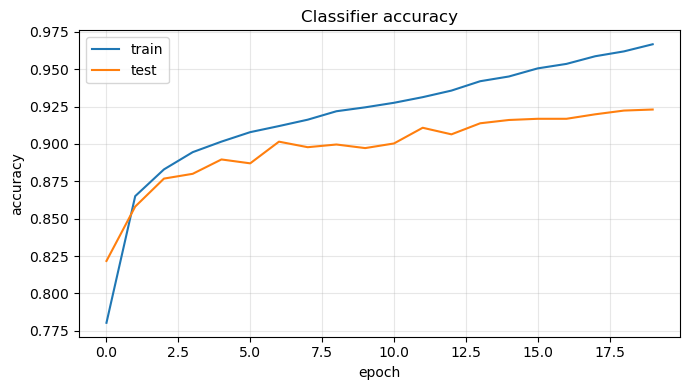

In [13]:
print("Loading Fashion-MNIST and training the classifier...")
train_loader, test_loader = get_fashion_mnist_dataloaders(batch_size=128)
classifier = FashionMNISTClassifier().to(device)
clf_history = train_classifier(classifier, train_loader, test_loader, num_epochs=NUM_CLASSIFIER_EPOCHS)

# TODO you can save the ckpt and load it afterwards to avoid having to wait for the classifier training while working on the GAN part.
# torch.save(classifier.state_dict(), "classifier_ckpt.pth")
# classifier.load_state_dict(torch.load("classifier_ckpt.pth"), strict=False)

plt.figure(figsize=(7, 4))
plt.plot(clf_history["acc_train"], label="train")
plt.plot(clf_history["acc_test"], label="test")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("Classifier accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [14]:
# Save the model's trained weights to a file
torch.save(classifier.state_dict(), "classifier_ckpt.pth")
print("Classifier saved successfully")

Classifier saved successfully


#### Train the baseline conditional DCGANb (Given)

Training the baseline conditional DCGAN...
  GAN epoch  1/15 | loss_d 1.014 loss_g 1.496 | acc_real 0.75 acc_fake 0.76 (11.7s)
  GAN epoch  2/15 | loss_d 0.753 loss_g 1.880 | acc_real 0.84 acc_fake 0.85 (11.2s)
  GAN epoch  3/15 | loss_d 0.459 loss_g 2.638 | acc_real 0.93 acc_fake 0.93 (14.2s)
  GAN epoch  4/15 | loss_d 0.300 loss_g 3.476 | acc_real 0.96 acc_fake 0.96 (11.2s)
  GAN epoch  5/15 | loss_d 0.232 loss_g 4.212 | acc_real 0.97 acc_fake 0.97 (11.3s)


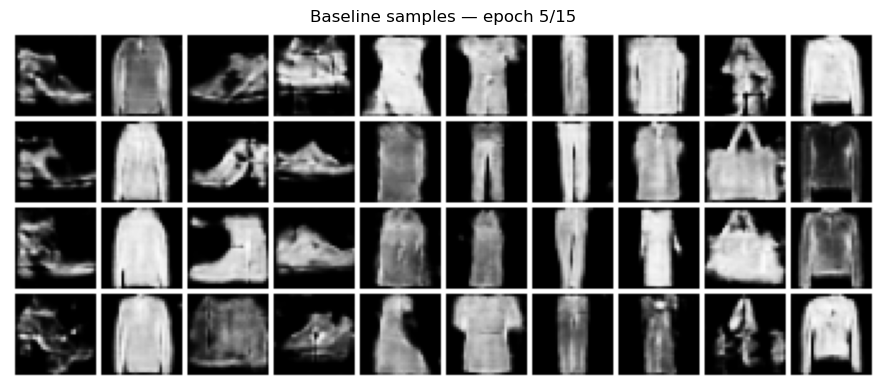

  GAN epoch  6/15 | loss_d 0.216 loss_g 4.816 | acc_real 0.97 acc_fake 0.97 (14.1s)
  GAN epoch  7/15 | loss_d 0.191 loss_g 5.187 | acc_real 0.98 acc_fake 0.98 (11.2s)
  GAN epoch  8/15 | loss_d 0.207 loss_g 5.487 | acc_real 0.98 acc_fake 0.98 (11.2s)
  GAN epoch  9/15 | loss_d 0.173 loss_g 5.726 | acc_real 0.98 acc_fake 0.98 (14.1s)
  GAN epoch 10/15 | loss_d 0.150 loss_g 5.903 | acc_real 0.98 acc_fake 0.99 (11.2s)


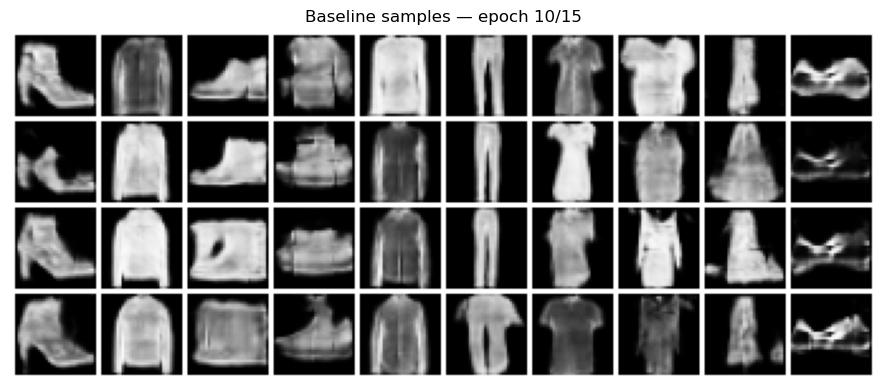

  GAN epoch 11/15 | loss_d 0.141 loss_g 6.258 | acc_real 0.99 acc_fake 0.99 (14.1s)
  GAN epoch 12/15 | loss_d 0.128 loss_g 6.385 | acc_real 0.98 acc_fake 0.99 (11.2s)
  GAN epoch 13/15 | loss_d 0.111 loss_g 7.006 | acc_real 0.99 acc_fake 0.99 (11.2s)
  GAN epoch 14/15 | loss_d 0.129 loss_g 6.950 | acc_real 0.98 acc_fake 0.99 (14.1s)
  GAN epoch 15/15 | loss_d 0.117 loss_g 7.444 | acc_real 0.98 acc_fake 0.99 (11.3s)


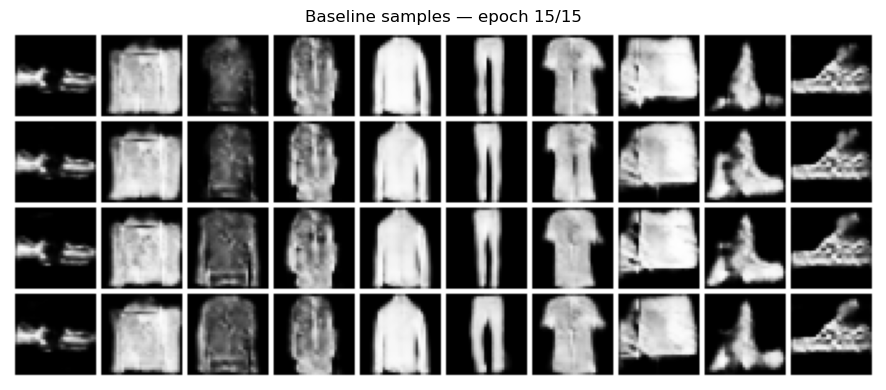

In [15]:
print("Training the baseline conditional DCGAN...")
z_dim = 100

# Baseline: vanilla DCGAN with no stabilisation tricks. With this recipe D
# quickly out-paces G: within ~10 epochs loss_d collapses toward 0 and
# loss_g diverges. This is the textbook unstable baseline Task 3 fixes.
generator = ConditionalGenerator(z_dim=z_dim).to(device)
discriminator = ConditionalDiscriminator(use_spectral_norm=False).to(device)

# Fixed 4x10 preview grid for the inline per-epoch dumps and the cross-epoch
# evolution figure: labels = [0..9, 0..9, 0..9, 0..9] so reshaping a stack
# of `fixed_samples` as (epochs, 4_samples, 10_classes, 1, 32, 32) keeps
# class on the third axis.
fixed_z = torch.randn(40, z_dim, device=device)
fixed_y = torch.arange(10, device=device).repeat(4)

baseline_history = train_gan(
    generator,
    discriminator,
    train_loader,
    num_epochs=NUM_GAN_EPOCHS,
    z_dim=z_dim,
    fixed_z=fixed_z,
    fixed_y=fixed_y,
    display_every=5,
    display_title="Baseline samples",
)

torch.save(generator.state_dict(), "generator_baseline.pth")

#### Reporting plots for Task 2 (TODO) (2P)
The loss curves and fixed samples should appear without any modification if your training loop for gan is correct. Only do the random sample part.

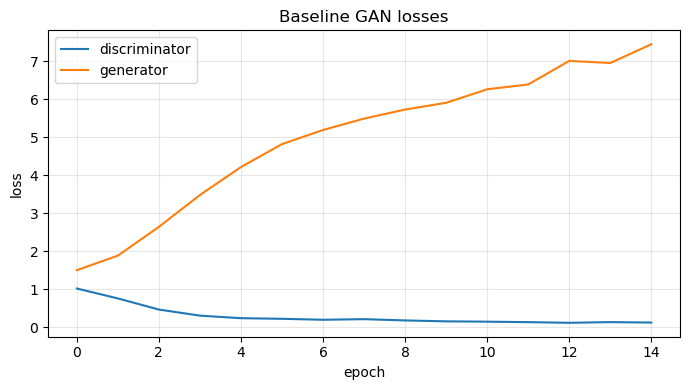

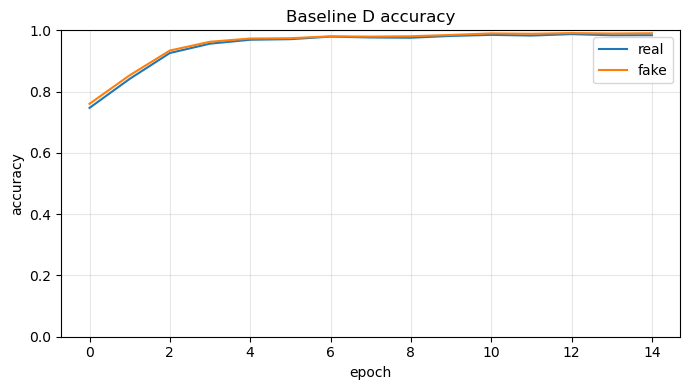

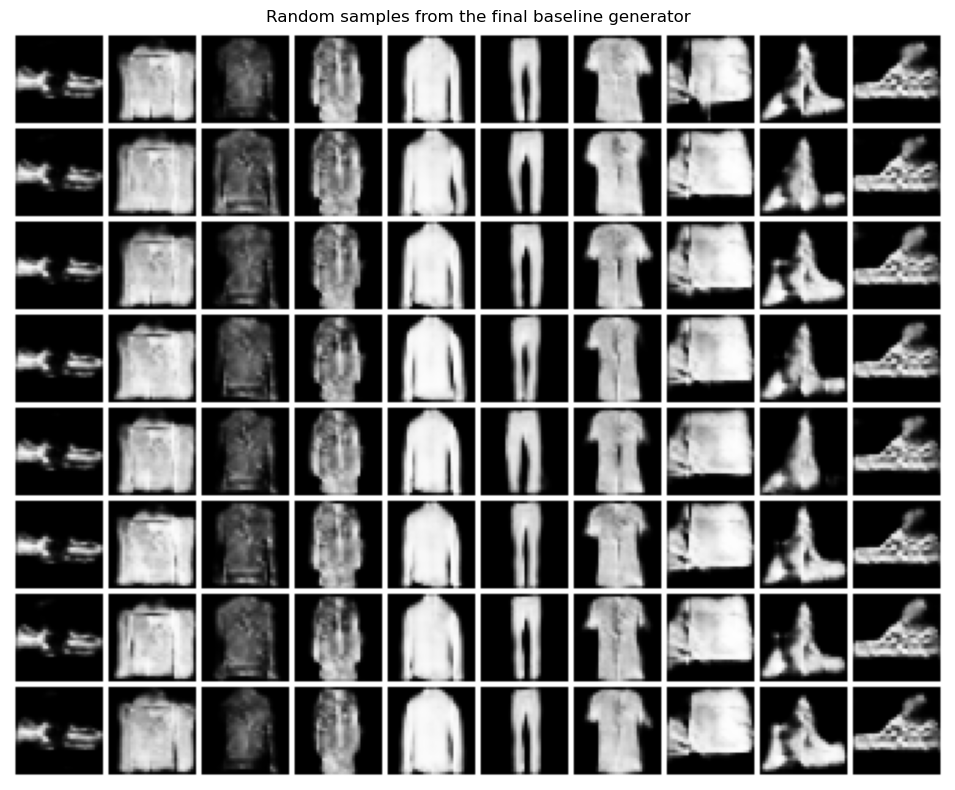

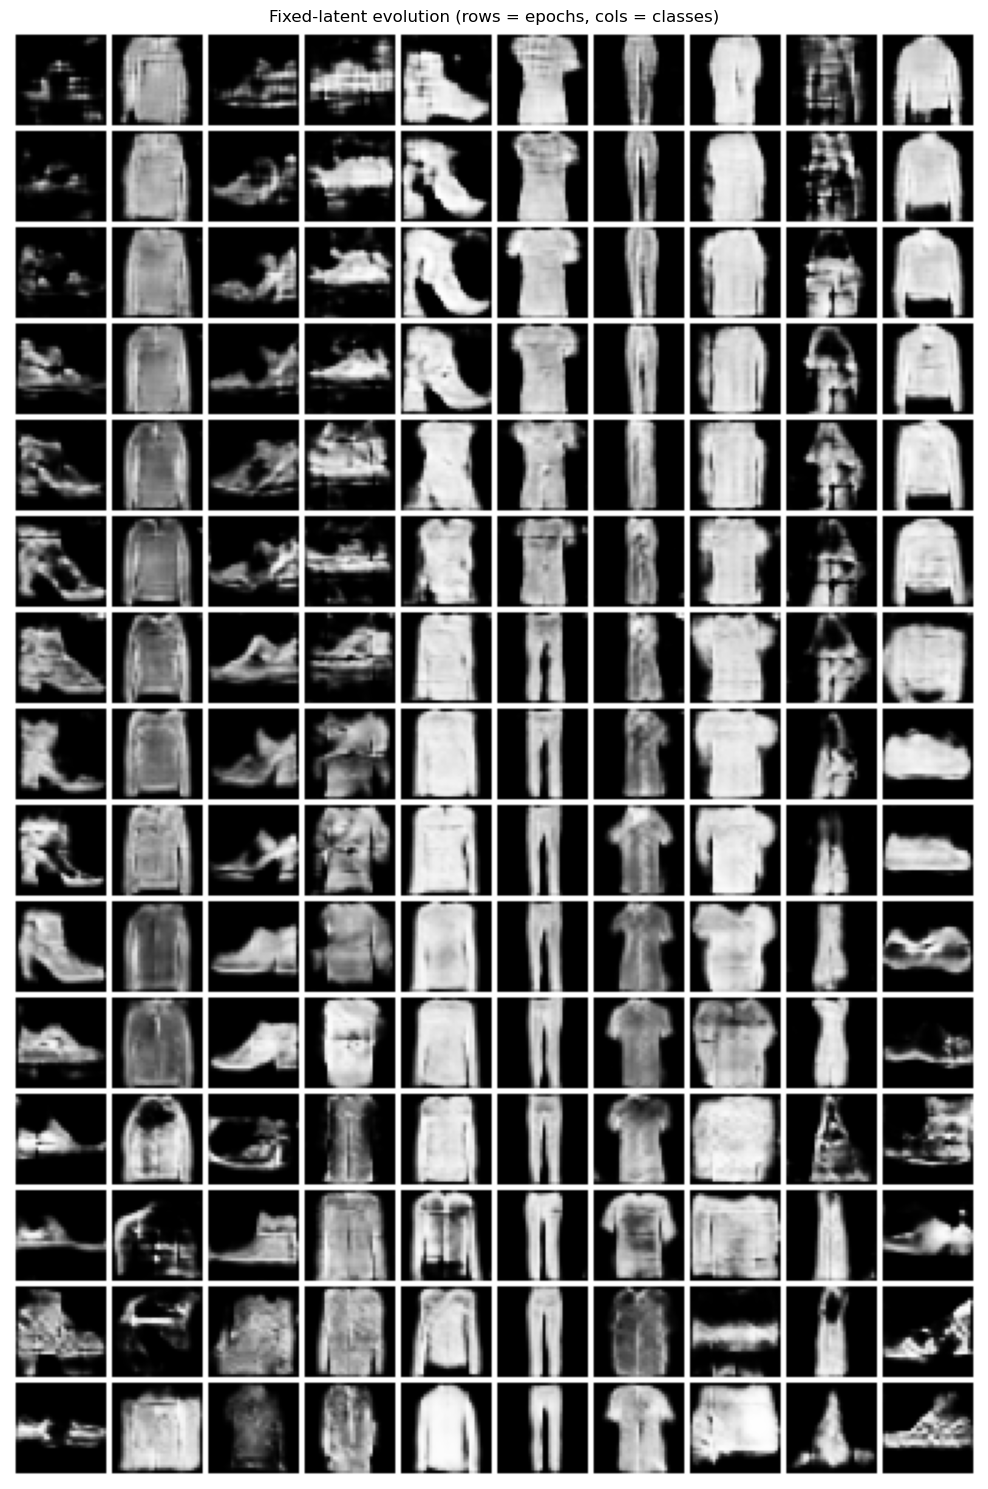

In [16]:
plot_losses(baseline_history, title="Baseline GAN losses")
plot_discriminator_accuracies(baseline_history, title="Baseline D accuracy")

# Final generated samples: 8 random latents per class -> 8x10 grid.
generator.eval()
with torch.no_grad():
    # TODO generate a batch of samples covering all classes, using random latents.
    z_rand = torch.randn(80, z_dim, device=device)
    y_rand = torch.arange(10, device=device).repeat(8)
    final_samples = generator(z_rand, y_rand)
    # TODO
    
plot_image_grid(final_samples, nrow=10, title="Random samples from the final baseline generator")



# Fixed-latent evolution figure: for at most 20 evenly-spaced epochs, take
# the first sample of each class (one row of the 4x10 fixed-grid preview).
fixed_samples = torch.stack(baseline_history["fixed_samples"], dim=0)  # [E, 40, 1, 32, 32]
fixed_samples = fixed_samples.view(fixed_samples.size(0), 4, 10, 1, 32, 32)[:, 0]  # [E, 10, 1, 32, 32]
ep_idx = np.linspace(0, fixed_samples.size(0) - 1, num=min(20, fixed_samples.size(0))).round().astype(int)
evolution = fixed_samples[ep_idx].reshape(-1, 1, 32, 32)
plot_image_grid(evolution, nrow=10, title="Fixed-latent evolution (rows = epochs, cols = classes)")


#### t-SNE embedding (TODO) (1P)

/tmp/ipykernel_12342/1962737590.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", 10)


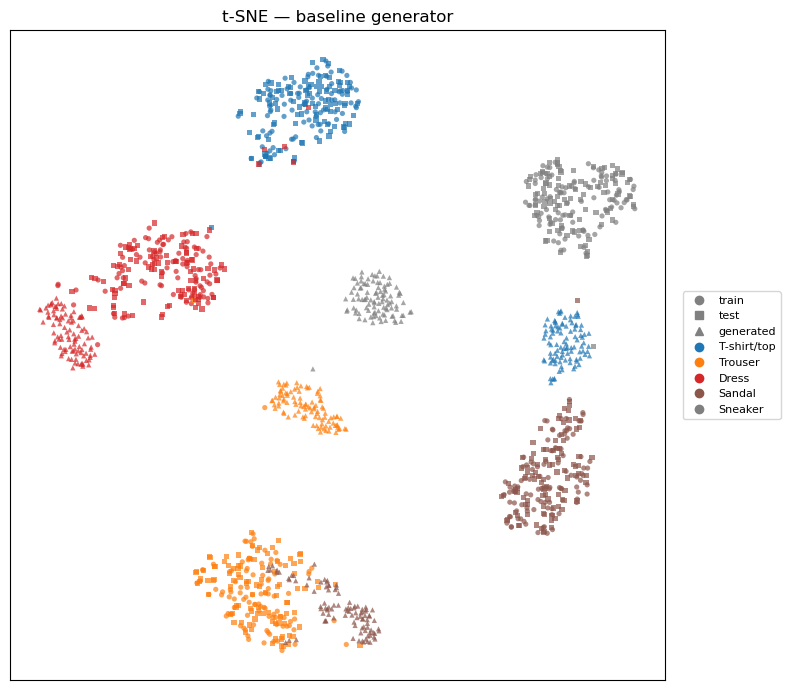

In [18]:
# Real train/test references used by every per-variant t-SNE in Tasks 2, 3 and the bonus.
N_PER_SOURCE = 100
TSNE_CLASSES = [0, 1, 3, 5, 7]
train_imgs, train_lbls = sample_per_class(train_loader, N_PER_SOURCE, TSNE_CLASSES)
test_imgs, test_lbls = sample_per_class(test_loader, N_PER_SOURCE, TSNE_CLASSES)


def tsne_for_generator(gen, title):
    """Run a train/test/generated t-SNE for `gen` and plot it (closes over the real samples above)."""
    gen.eval()
    with torch.no_grad():

        # TODO generate a batch of samples covering all TSNE_CLASSES, using random latents. 
        # Similar to the final_samples generation above but only for the TSNE_CLASSES and with N_PER_SOURCE samples per class.
        z_tsne = torch.randn(len(TSNE_CLASSES) * N_PER_SOURCE, z_dim, device=device)
        y_tsne = torch.tensor(TSNE_CLASSES, device=device).repeat_interleave(N_PER_SOURCE)
        
        gen_imgs = gen(z_tsne, y_tsne).cpu()
        # TODO

    gen_lbls = np.concatenate([np.full(N_PER_SOURCE, c) for c in TSNE_CLASSES])

    all_imgs = torch.cat([train_imgs, test_imgs, gen_imgs], dim=0)
    all_labels = np.concatenate([train_lbls, test_lbls, gen_lbls])
    all_domains = ["train"] * train_imgs.size(0) + ["test"] * test_imgs.size(0) + ["generated"] * gen_imgs.size(0)
    feats = extract_classifier_features(classifier, all_imgs)
    run_tsne(feats, all_labels, all_domains, title=title)


tsne_for_generator(generator, title="t-SNE — baseline generator")


#### Classifier accuracy on generated samples (TODO) (1P)

In [20]:
@torch.no_grad()
def compute_generated_classifier_accuracy(generator, classifier, num_samples_per_class=200, z_dim=100):
    """Generate `num_samples_per_class` images per class, classify them, and return overall accuracy."""
    generator.eval()
    classifier.eval()
    correct, total = 0, 0
    for cls in range(10):
        # TODO generate a batch of samples for class `cls` using random latents and the provided `num_samples_per_class` and `z_dim` parameters.
        # classify them with `classifier` and compare to the true class `cls` to accumulate the number of correct predictions in `correct` and the total number of samples in `total`.
        # Generate `num_samples_per_class` for current `cls`
        z = torch.randn(num_samples_per_class, z_dim, device=device)
        y = torch.full((num_samples_per_class,), cls, dtype=torch.long, device=device)
        
        imgs = generator(z, y)
        logits = classifier(imgs)
        preds = logits.argmax(dim=1)
        # TODO
        correct += (preds == y).sum().item()
        total += num_samples_per_class
    return correct / total


gen_acc = compute_generated_classifier_accuracy(generator, classifier, num_samples_per_class=200, z_dim=z_dim)
print(f"Baseline classifier accuracy on generated samples: {gen_acc:.3f}")

Baseline classifier accuracy on generated samples: 0.141


## Task 3 — GAN Stabilization Study (10P)

The Task 2 baseline is the vanilla DCGAN recipe with no stabilization
tricks: with that setup $D$ quickly overpowers $G$, $\mathcal{L}_D$
collapses to $\approx 0$, $\mathcal{L}_G$ diverges, and the generator
stops improving. In this task you investigate **two** different ways of
keeping $D$ from running away — pick any two of the variants A, B, C below,
train them with the same budget as the baseline, and compare loss curves,
discriminator accuracies, generated samples, classifier accuracy on
generated samples, and t-SNE embeddings of generated vs. real data. Write
a short discussion for each variant.

| Variant | Idea |
|---|---|
| A | Spectral normalization on the discriminator (bounds the Lipschitz constant of $D$) |
| B | One-sided label smoothing (real labels $\to 0.9$) |
| C | R1 gradient penalty $\tfrac{\gamma}{2}\mathbb{E}_{x\sim p_{\text{data}}}\|\nabla_x D(x,y)\|_2^2$ on real images (given) |

The `variant_config` dictionary below is passed to `train_gan` and controls
which mechanism is active. Flip the appropriate flags (and the
`use_spectral_norm` constructor argument of `ConditionalDiscriminator` for
Variant A) to obtain each variant.


We train all three variants (A: spectral normalisation, B: one-sided label smoothing, C: R1 gradient penalty) as a reference. Any two of them are sufficient for full credit.

#### Variant A — Spectral normalisation (TODO)
For this task you only have to modify your `ConditionalDiscriminator`

In [ ]:
print("Variant A: spectral normalization on D")
g_a = ConditionalGenerator(z_dim=z_dim).to(device)
d_a = ConditionalDiscriminator(use_spectral_norm=True).to(device)
history_a = train_gan(
    g_a,
    d_a,
    train_loader,
    num_epochs=NUM_GAN_EPOCHS,
    z_dim=z_dim,
    variant_config={"spectral_norm": True},
    fixed_z=fixed_z,
    fixed_y=fixed_y,
    display_every=5,
    display_title="Variant A samples",
)

torch.save(g_a.state_dict(), "generator_variant_a.pth")

tsne_for_generator(g_a, title="t-SNE — variant A (spectral norm)")


#### Variant B — One-sided label smoothing (TODO)
For this task you only have to modify your `train_gan()`

In [ ]:
print("Variant B: one-sided label smoothing")
g_b = ConditionalGenerator(z_dim=z_dim).to(device)
d_b = ConditionalDiscriminator(use_spectral_norm=False).to(device)
history_b = train_gan(
    g_b,
    d_b,
    train_loader,
    num_epochs=NUM_GAN_EPOCHS,
    z_dim=z_dim,
    variant_config={"label_smoothing": True, "real_label_value": 0.9},
    fixed_z=fixed_z,
    fixed_y=fixed_y,
    display_every=5,
    display_title="Variant B samples",
)

torch.save(g_b.state_dict(), "generator_variant_b.pth")

tsne_for_generator(g_b, title="t-SNE — variant B (label smoothing)")


#### Variant C — R1 gradient penalty (Just run and discuss)

In [ ]:
print("Variant C: R1 gradient penalty on real images")
g_c = ConditionalGenerator(z_dim=z_dim).to(device)
d_c = ConditionalDiscriminator(use_spectral_norm=False).to(device)
history_c = train_gan(
    g_c,
    d_c,
    train_loader,
    num_epochs=NUM_GAN_EPOCHS,
    z_dim=z_dim,
    variant_config={"r1_regularization": True, "r1_gamma": 10.0},
    fixed_z=fixed_z,
    fixed_y=fixed_y,
    display_every=5,
    display_title="Variant C samples",
)

torch.save(g_c.state_dict(), "generator_variant_c.pth")

tsne_for_generator(g_c, title="t-SNE — variant C (R1 penalty)")


#### Comparison plots (Given) (1P)

In [ ]:
# Same set of (name, history) / (name, generator) pairs used for all three comparison plots below.
named_histories = [
    ("baseline", baseline_history),
    ("variant A (SN)", history_a),
    ("variant B (LS)", history_b),
    ("variant C (R1)", history_c),
]
named_generators = [
    ("baseline", generator),
    ("variant A (SN)", g_a),
    ("variant B (LS)", g_b),
    ("variant C (R1)", g_c),
]

# Loss curves.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, key, ylabel in zip(axes, ["loss_d", "loss_g"], ["D loss", "G loss"]):
    for name, hist in named_histories:
        ax.plot(hist[key], label=name)
    ax.set_xlabel("epoch")
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(alpha=0.3)
fig.suptitle("Loss comparison: baseline vs. stabilisation variants")
plt.tight_layout()
plt.show()

# D accuracy curves.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, key, ylabel in zip(axes, ["acc_real", "acc_fake"], ["D accuracy on real", "D accuracy on fake"]):
    for name, hist in named_histories:
        ax.plot(hist[key], label=name)
    ax.set_xlabel("epoch")
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(alpha=0.3)
fig.suptitle("Discriminator accuracy comparison")
plt.tight_layout()
plt.show()

# 4x10 sample grid per variant.
y_all = torch.arange(10, device=device).repeat(4)
for name, gen in named_generators:
    gen.eval()
    with torch.no_grad():
        samples = gen(torch.randn(40, z_dim, device=device), y_all)
    plot_image_grid(samples, nrow=10, scale=1.4, title=f"Samples — {name}")

# Per-variant classifier accuracy on generated samples.
print("Classifier accuracy on generated samples:")
for name, gen in named_generators:
    acc = compute_generated_classifier_accuracy(gen, classifier, num_samples_per_class=200, z_dim=z_dim)
    print(f"  {name:18s}: {acc:.3f}")


### Task 3 — Discussion (TODO) (2P)

**Variant A — Spectral normalization.** 

**Variant B — One-sided label smoothing.** 

**Variant C — R1 gradient penalty.** 

*(Students should write their own paragraph replacing these, grounded in
the plots above.)*


## Task 4 — Conditional Control and Interpolation (4P)

Use your best generator (Task 2 or Task 3) to test whether it actually uses
both the latent code and the class label.

- **4a.** Fix one latent code $z$ and generate $G(z,y)$ for $y=0,\dots,9$.
- **4b.** Fix one class label $y$ and interpolate spherically between two
  latent codes $z_1, z_2 \sim \mathcal{N}(0, I)$:
  $z_\alpha = \frac{\sin((1-\alpha)\omega)}{\sin\omega} z_1 + \frac{\sin(\alpha\omega)}{\sin\omega} z_2$
  with $\omega = \arccos(\langle\hat z_1, \hat z_2\rangle)$ and
  $\alpha\in[0,1]$. This is variance-preserving — plain linear interpolation
  shrinks $\|z_\alpha\|$ at the midpoint and pulls samples off the typical
  $\mathcal{N}(0, I)$ shell the generator was trained on.
- **4c.** Fix one latent code $z$ and interpolate **linearly** between the
  class embeddings of two classes:
  $e_\alpha = (1-\alpha)\,G.\text{embed}(y_1) + \alpha\,G.\text{embed}(y_2)$
  with $\alpha\in[0,1]$, then push $(z, e_\alpha)$ through the rest of the
  generator. This visualises the *conditional* manifold the generator has
  learned: 4a gives you discrete class jumps at the endpoints, 4c gives you
  the continuous path between them.
- **4d.** Discuss class controllability, smoothness of the within-class
  $z$-interpolation, smoothness of the class-to-class morph, and any
  apparent ignorance of $z$ or $y$.


#### Latent-space helpers for Task 4 (Given)

In [ ]:
def slerp(z1, z2, alpha):
    """Spherical linear interpolation between two latent codes (Task 4b).

    Variance preserving: `|slerp(z1, z2, alpha)|` stays close to `|z1|, |z2|`
    for every alpha in [0, 1]. Plain LERP shrinks the norm at the midpoint
    by ~1/sqrt(2) and pulls samples off the typical N(0, I) shell the
    generator was trained on. See White (2016), "Sampling Generative
    Networks" (https://arxiv.org/abs/1609.04468).
    """
    z1_flat, z2_flat = z1.flatten(), z2.flatten()
    cos_omega = (z1_flat / z1_flat.norm()).dot(z2_flat / z2_flat.norm()).clamp(-1.0, 1.0)
    omega = torch.acos(cos_omega)
    if omega.abs() < 1e-6:
        return (1 - alpha) * z1 + alpha * z2
    return (torch.sin((1 - alpha) * omega) * z1 + torch.sin(alpha * omega) * z2) / torch.sin(omega)


def generate_from_embedding(generator, z, class_embedding):
    """Run `generator` with an arbitrary class embedding instead of an integer label (Task 4c).

    Mirrors `ConditionalGenerator.forward`, but skips the embedding lookup
    so we can feed interpolated embeddings directly.
    """
    h = torch.cat([z, class_embedding], dim=1)
    h = generator.proj(h).view(z.size(0), -1, 4, 4)
    return generator.net(h)


#### TODO

In [ ]:
# Use the best generator we have available: the vanilla baseline diverged,
# so we use the spectral-normalisation variant from Task 3.
# (slerp and generate_from_embedding are pre-defined in the "Shared helpers" section.)

G_best = None  # TODO: choose your best generator from above, you can also load them from ckpt if you saved them.
G_best.eval()

N_INTERP = 11
alphas = torch.linspace(0, 1, N_INTERP, device=device)

# --- Task 4a: fixed z, vary the class label ---
with torch.no_grad():
    # TODO
    # Your code for Task 4a here: generate a batch of samples with a fixed latent code and class labels from
    # TODO
plot_image_grid(samples_a, nrow=10, scale=1.5, title="Task 4a — fixed z, y = 0..9")

# --- Task 4b: fixed class, slerp interpolation between two random latents ---
with torch.no_grad():
    for class_idx in [3, 7]:  # Dress, Sneaker
        # TODO
        # Your code for Task 4b here: sample two random latent codes z1, z2 and generate a batch of samples by slerp-interpolating 
        # between them with the fixed class label `class_idx`.
        # TODO
        plot_image_grid(
            G_best(zs, y),
            nrow=N_INTERP,
            scale=1.5,
            title=f"Task 4b — slerp(z1, z2), fixed y = {FASHION_CLASSES[class_idx]}",
        )

# --- Task 4c: fixed z, linear interpolation between two class embeddings ---
# The embedding space is learned end-to-end (not constrained to a sphere),
# so plain LERP is the natural choice here.
alphas_col = alphas.view(-1, 1)
with torch.no_grad():
    # TODO Your code for Task 4c here: generate two batches of samples by linearly interpolating between the class embeddings of two pairs of 
    # classes (e.g. Dress -> Sneaker, Bag -> Ankle boot) with a fixed latent code. You can change the class pairs if you like, 
    # but make sure to include at least one pair of visually distinct classes and one pair of visually similar classes.
    for class_a, class_b in [(3, 7), (8, 9)]:
        # TODO compute the class embedding interpolation `e_interp` between the embeddings of `class_a` and `class_b` using `alphas_col`.
        plot_image_grid(
            generate_from_embedding(G_best, z_fix, e_interp),
            nrow=N_INTERP,
            scale=1.5,
            title=f"Task 4c — {FASHION_CLASSES[class_a]} → {FASHION_CLASSES[class_b]} (fixed z)",
        )



### Task 4d — Discussion (TODO)

*(Students should replace this with
their own observations grounded in the figures above.)*


## Task 5 — Confusion Matrix on Generated Data (4P)

Generate a balanced class-conditional sample set (e.g. 100–500 samples per
class) and classify each generated image with the Task 2 classifier. Report
the confusion matrix (rows: conditioning label, columns: classifier
prediction), the per-class generated accuracy, and a short discussion of the
most common confusions.


#### Create a balanced class-conditional samples set and compute the confusion matrix (TODO)

In [ ]:
@torch.no_grad()
def compute_generated_confusion_matrix(generator, classifier, num_samples_per_class=200, z_dim=100):
    """Same as above but return (confusion_matrix, per_class_accuracy)."""
    generator.eval()
    classifier.eval()
    cm = np.zeros((10, 10), dtype=np.int64)
    for cls in range(10):
        # TODO generate a batch of samples for class `cls` using random latents and the provided `num_samples_per_class` and `z_dim` parameters.
        # classify them with `classifier` and update the confusion matrix `cm` accordingly.
        # TODO
    per_class_acc = cm.diagonal() / cm.sum(axis=1).clip(min=1)
    return cm, per_class_acc

#### The following code should run smoothly if the above cell is correct. You can change some arg, e.g., num_samples_per_class, to play around a bit. (Given)

In [ ]:
# Confusion matrix on the best generator (variant A — spectral norm).
cm, per_class_acc = compute_generated_confusion_matrix(g_a, classifier, num_samples_per_class=200, z_dim=z_dim)
plot_confusion_matrix(cm, FASHION_CLASSES, title="Confusion matrix on generated samples")

plt.figure(figsize=(8, 3))
plt.bar(FASHION_CLASSES, per_class_acc)
plt.xticks(rotation=45, ha="right")
plt.ylabel("accuracy")
plt.title("Per-class generated accuracy")
plt.tight_layout()
plt.show()

print("Per-class generated accuracy:")
for cls, acc in zip(FASHION_CLASSES, per_class_acc):
    print(f"  {cls:14s}: {acc:.3f}")
print(f"Overall:        {per_class_acc.mean():.3f}")


### Task 5 — Discussion (TODO)
*(Students should replace this
with their own discussion grounded in the matrix above.)*


## Bonus — Combining Variant A + C (spectral norm + R1 penalty)

Variants A (spectral normalization on $D$) and C (R1 gradient penalty on
real images) attack the same problem from different angles: A bounds the
*global* Lipschitz constant of $D$ via the layer operator norms, while C
penalises the *local* gradient norm of $D$ on the real-data manifold. They
are complementary and routinely stacked in practice (e.g. StyleGAN2/3 use
both R1 and a Lipschitz-style regulariser). In this bonus we train one
generator with both mechanisms enabled and compare it to the individual
variants on classifier accuracy and t-SNE clustering.


In [ ]:
print("Bonus: combined variant A + C (spectral norm + R1 penalty)")

# TODO implement the combined variant A + C by applying spectral normalization to the discriminator and adding the R1 penalty to the discriminator loss. You can reuse the ConditionalGenerator and ConditionalDiscriminator classes, but make sure to set use_spectral_norm=True when instantiating the discriminator and to include the R1 penalty in the train_gan call.
g_ac = None
d_ac = None
history_ac = train_gan(
    g_ac,
    d_ac,
    train_loader,
    num_epochs=NUM_GAN_EPOCHS,
    z_dim=z_dim,
    variant_config={...}, # TODO set the correct config for R1 penalty
    fixed_z=fixed_z,
    fixed_y=fixed_y,
    display_every=5,
    display_title="Bonus A+C samples",
)
# TODO

plot_losses(history_ac, title="Bonus (A+C) GAN losses")
plot_discriminator_accuracies(history_ac, title="Bonus (A+C) D accuracy")

g_ac.eval()
with torch.no_grad():
    samples_ac = g_ac(torch.randn(40, z_dim, device=device), torch.arange(10, device=device).repeat(4))
plot_image_grid(samples_ac, nrow=10, scale=1.4, title="Bonus — random samples (variant A + C)")

print("\nClassifier accuracy on generated samples (recap):")
for name, gen in [
    ("baseline", generator),
    ("variant A (SN)", g_a),
    ("variant B (LS)", g_b),
    ("variant C (R1)", g_c),
    ("bonus A+C", g_ac),
]:
    acc = compute_generated_classifier_accuracy(gen, classifier, num_samples_per_class=200, z_dim=z_dim)
    print(f"  {name:18s}: {acc:.3f}")

tsne_for_generator(g_ac, title="t-SNE — bonus (variant A + C)")


### Bonus — Discussion (TODO)
*(Students should replace this with their
own discussion grounded in the figures above.)*
